# Customer Retention & Churn Analysis

## Future Interns – Data Science & Analytics Task 2

This project analyzes customer and subscription data to understand churn patterns, customer retention, customer lifetime trends, and key factors associated with customer churn.

### Objectives
- Analyze customer churn and retention
- Identify important churn drivers
- Analyze customer tenure and lifetime patterns
- Compare churn across customer segments
- Generate actionable recommendations to improve retention

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [39]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [38]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Flag          0
Tenure_Group        0
dtype: int64

## 2. Data Cleaning and Preparation

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [10]:
df['Churn_Flag'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [11]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months']
)

In [12]:
df[['tenure', 'Tenure_Group', 'Churn', 'Churn_Flag']].head()

,tenure,Tenure_Group,Churn,Churn_Flag
0,1,0-12 Months,No,0
1,34,25-48 Months,No,0
2,2,0-12 Months,Yes,1
3,45,25-48 Months,No,0
4,2,0-12 Months,Yes,1


## 3. Customer Retention & Churn KPIs

In [13]:
total_customers = df['customerID'].nunique()
churned_customers = df['Churn_Flag'].sum()
retained_customers = total_customers - churned_customers

churn_rate = (churned_customers / total_customers) * 100
retention_rate = (retained_customers / total_customers) * 100

average_tenure = df['tenure'].mean()
total_monthly_charges = df['MonthlyCharges'].sum()
average_monthly_charge = df['MonthlyCharges'].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Retention Rate:", round(retention_rate, 2), "%")
print("Average Tenure:", round(average_tenure, 2), "months")
print("Total Monthly Charges:", round(total_monthly_charges, 2))
print("Average Monthly Charge:", round(average_monthly_charge, 2))

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate: 26.54 %
Retention Rate: 73.46 %
Average Tenure: 32.37 months
Total Monthly Charges: 456116.6
Average Monthly Charge: 64.76


In [14]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Churned Customers',
        'Retained Customers',
        'Churn Rate',
        'Retention Rate',
        'Average Tenure (Months)',
        'Average Monthly Charge'
    ],
    'Value': [
        total_customers,
        churned_customers,
        retained_customers,
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(average_tenure, 2),
        round(average_monthly_charge, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Retained Customers,5174.00
3,Churn Rate,26.54
4,Retention Rate,73.46
5,Average Tenure (Months),32.37
6,Average Monthly Charge,64.76


## 4. Churn Analysis by Customer Segments

### Cohort Analysis Note

The dataset does not contain a customer signup date, so signup-month cohort analysis is not possible. Instead, customers are grouped into tenure-based cohorts to analyze retention and churn patterns across different stages of the customer lifecycle.

In [15]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [16]:
contract_churn_rate = (
    df.groupby('Contract')['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn_Flag, dtype: float64

In [17]:
tenure_churn = (
    df.groupby('Tenure_Group', observed=True)['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
)

tenure_churn

Tenure_Group
0-12 Months     47.44
13-24 Months    28.71
25-48 Months    20.39
49-72 Months     9.51
Name: Churn_Flag, dtype: float64

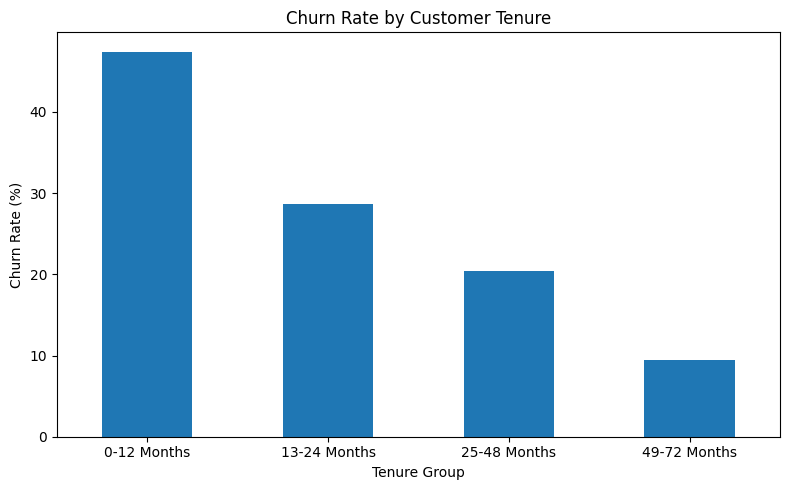

In [18]:
plt.figure(figsize=(8, 5))

tenure_churn.plot(kind='bar')

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn_Flag, dtype: float64

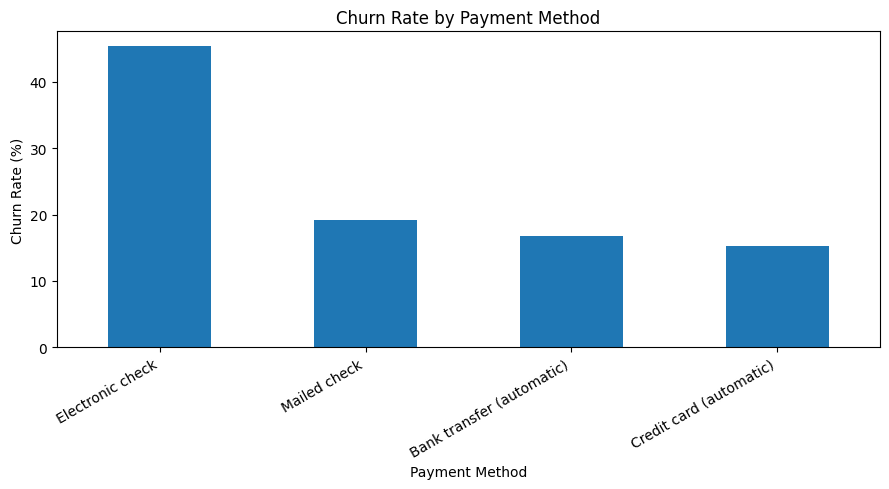

In [20]:
plt.figure(figsize=(9, 5))

payment_churn.plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Retention Drivers and Churn Factors

### Churn Reason Note

The dataset does not contain a specific churn-reason field. Therefore, this analysis focuses on customer characteristics and service factors that are associated with higher churn rates, such as contract type, tenure, payment method, internet service, online security, and technical support.

In [21]:
internet_churn = (
    df.groupby('InternetService')['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

internet_churn

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn_Flag, dtype: float64

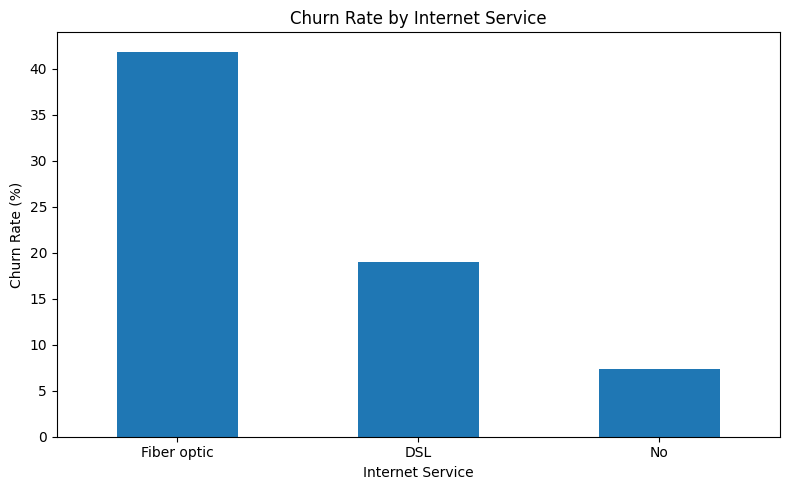

In [22]:
plt.figure(figsize=(8, 5))

internet_churn.plot(kind='bar')

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
security_churn = (
    df.groupby('OnlineSecurity')['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

security_churn

OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn_Flag, dtype: float64

In [24]:
support_churn = (
    df.groupby('TechSupport')['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

support_churn

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn_Flag, dtype: float64

In [25]:
senior_churn = (
    df.groupby('SeniorCitizen')['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
)

senior_churn.index = ['Non-Senior', 'Senior']

senior_churn

Non-Senior    23.61
Senior        41.68
Name: Churn_Flag, dtype: float64

In [26]:
partner_churn = (
    df.groupby('Partner')['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
)

dependents_churn = (
    df.groupby('Dependents')['Churn_Flag']
    .mean()
    .mul(100)
    .round(2)
)

print("Partner:")
print(partner_churn)

print("\nDependents:")
print(dependents_churn)

Partner:
Partner
No     32.96
Yes    19.66
Name: Churn_Flag, dtype: float64

Dependents:
Dependents
No     31.28
Yes    15.45
Name: Churn_Flag, dtype: float64


In [27]:
driver_summary = pd.DataFrame({
    'Factor': [
        'Contract',
        'Tenure',
        'Payment Method',
        'Internet Service',
        'Online Security',
        'Tech Support'
    ],
    'Analysis': [
        contract_churn_rate.to_dict(),
        tenure_churn.to_dict(),
        payment_churn.to_dict(),
        internet_churn.to_dict(),
        security_churn.to_dict(),
        support_churn.to_dict()
    ]
})

driver_summary

,Factor,Analysis
0,Contract,"{'Month-to-month': 42.71, 'One year': 11.27, '..."
1,Tenure,"{'0-12 Months': 47.44, '13-24 Months': 28.71, ..."
2,Payment Method,"{'Electronic check': 45.29, 'Mailed check': 19..."
3,Internet Service,"{'Fiber optic': 41.89, 'DSL': 18.96, 'No': 7.4}"
4,Online Security,"{'No': 41.77, 'Yes': 14.61, 'No internet servi..."
5,Tech Support,"{'No': 41.64, 'Yes': 15.17, 'No internet servi..."


## 6. Customer Lifetime Analysis

In [28]:
lifetime_summary = df.groupby('Churn').agg(
    Customers=('customerID', 'count'),
    Average_Tenure=('tenure', 'mean'),
    Average_Monthly_Charges=('MonthlyCharges', 'mean'),
    Average_Total_Charges=('TotalCharges', 'mean')
).round(2)

lifetime_summary

,Customers,Average_Tenure,Average_Monthly_Charges,Average_Total_Charges
Churn,,,,
No,5174,37.57,61.27,2550.0
Yes,1869,17.98,74.44,1531.8


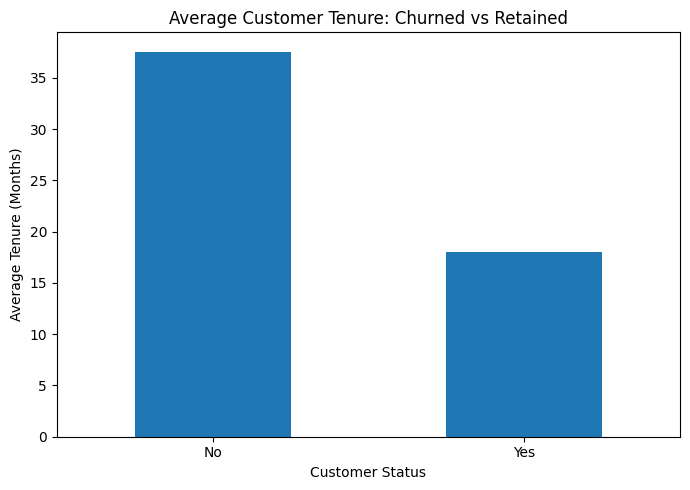

In [29]:
plt.figure(figsize=(7, 5))

df.groupby('Churn')['tenure'].mean().plot(kind='bar')

plt.title('Average Customer Tenure: Churned vs Retained')
plt.xlabel('Customer Status')
plt.ylabel('Average Tenure (Months)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

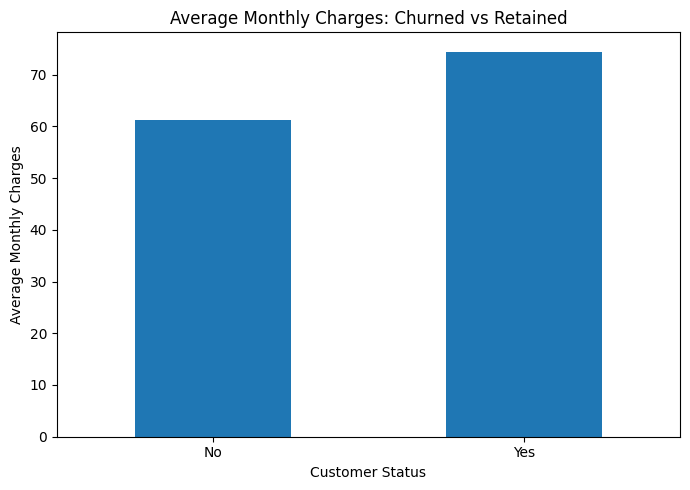

In [30]:
plt.figure(figsize=(7, 5))

df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar')

plt.title('Average Monthly Charges: Churned vs Retained')
plt.xlabel('Customer Status')
plt.ylabel('Average Monthly Charges')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

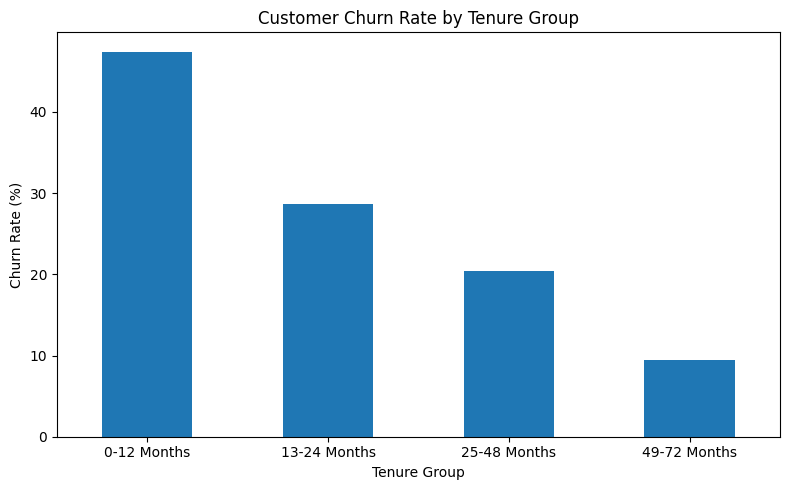

In [31]:
plt.figure(figsize=(8, 5))

tenure_churn.plot(kind='bar')

plt.title('Customer Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

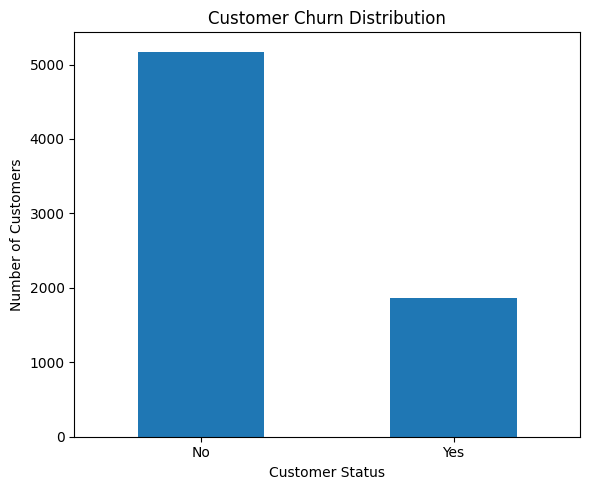

In [32]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 5))

churn_counts.plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Key Business Insights

In [33]:
overall_summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Churned Customers',
        'Retained Customers',
        'Churn Rate (%)',
        'Retention Rate (%)',
        'Average Tenure (Months)',
        'Average Monthly Charge'
    ],
    'Value': [
        total_customers,
        churned_customers,
        retained_customers,
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(average_tenure, 2),
        round(average_monthly_charge, 2)
    ]
})

overall_summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Retained Customers,5174.00
3,Churn Rate (%),26.54
4,Retention Rate (%),73.46
5,Average Tenure (Months),32.37
6,Average Monthly Charge,64.76


In [34]:
highest_contract_churn = contract_churn_rate.idxmax()
highest_contract_rate = contract_churn_rate.max()

print("Highest Churn Contract:", highest_contract_churn)
print("Churn Rate:", highest_contract_rate, "%")

Highest Churn Contract: Month-to-month
Churn Rate: 42.71 %


In [35]:
highest_tenure_churn = tenure_churn.idxmax()
highest_tenure_rate = tenure_churn.max()

print("Highest Churn Tenure Group:", highest_tenure_churn)
print("Churn Rate:", highest_tenure_rate, "%")

Highest Churn Tenure Group: 0-12 Months
Churn Rate: 47.44 %


In [36]:
highest_payment_churn = payment_churn.idxmax()
highest_payment_rate = payment_churn.max()

print("Highest Churn Payment Method:", highest_payment_churn)
print("Churn Rate:", highest_payment_rate, "%")

Highest Churn Payment Method: Electronic check
Churn Rate: 45.29 %


## 8. Business Recommendations

### 1. Strengthen Early Customer Retention
Customers in the early stages of their relationship should receive stronger onboarding, product education, and engagement campaigns.

### 2. Encourage Longer-Term Contracts
Customers on higher-risk contract types should be targeted with incentives to move toward longer-term plans.

### 3. Focus on High-Risk Customer Segments
Use churn patterns by tenure, payment method, internet service, and customer characteristics to identify customers who need proactive retention support.

### 4. Improve Customer Support
Customers without services such as online security and technical support should be evaluated for higher churn risk, and relevant support packages can be promoted.

### 5. Monitor High Monthly Charges
Customers with higher monthly charges may require additional value communication, personalized offers, or plan optimization.

### 6. Build a Proactive Churn Program
Use customer-level churn indicators to identify at-risk customers before they leave and trigger targeted retention campaigns.

## 9. Conclusion

This analysis provides a clear view of customer churn and retention patterns.

The analysis identifies important differences in churn across contract types, tenure groups, payment methods, services, and customer characteristics. Customer lifetime analysis also highlights how tenure and monthly charges differ between churned and retained customers.

These findings can help a subscription business improve onboarding, encourage longer-term relationships, target high-risk customers, and develop proactive retention strategies.